# Validation methods for time series

Almost every machine-learning workflow ends with the same question: *how well will this model do on data it has never seen?* The usual answer is cross-validation — shuffle the rows, hold some out, score, repeat. That recipe quietly assumes the rows are interchangeable draws from one fixed distribution. **Time series break that assumption.** Observations arrive in an order, and that order carries information.

This notebook is about what goes wrong when you ignore the order, and the ladder of techniques that put it back. The organising principle is the **arrow of time**: cause precedes effect, so the data used to make a forecast at time *t* must come only from times at or before *t*. Any validation scheme that lets information from *t+1* influence a prediction for *t* is, in effect, testing the model's ability to *predict the past* — a skill that evaporates the moment the model meets genuinely future data.

We will build a deliberately small, fully synthetic "market" so that we know the ground truth, then walk a single dataset through six validation strategies, from the most broken to the most robust:

1. **Random split** — the most direct violation of the arrow of time.
2. **K-Fold** — random splitting with extra steps; the same disease.
3. **Walk-forward (`TimeSeriesSplit`)** — the first honest method: train always precedes test.
4. **Group time-series split** — keeps each time-stamp's rows together, for panel data.
5. **Purged group time-series split** — removes leakage from rolling features and path-dependent labels.
6. **Combinatorial Purged CV (CPCV)** — stops trusting a single history and reports a *distribution* of performance.

Each rung fixes exactly one new problem. By the end we will have a single comparison table that quantifies how badly each method lied to us.

# Setup

In [1]:
# Standard library imports
import warnings

# Third-party imports: core data -> modeling -> visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split, KFold, TimeSeriesSplit

from scipy.special import comb
from itertools import combinations

# Configuration & settings
warnings.simplefilter(action='ignore', category=FutureWarning)

The imports are grouped on purpose, and the grouping is the same one used throughout this series: first the **standard library** (here just `warnings`, to silence the deprecation chatter that would otherwise clutter the output), then **third-party** packages ordered *core data → modelling → visualisation*, and finally any one-off helpers.

A few things worth naming explicitly for readers newer to the scientific-Python stack:

- `import numpy as np` and `import pandas as pd` bind the libraries to short **aliases**. `np` is the array/maths workhorse; `pd` gives us the `DataFrame`, a spreadsheet-like table that is the natural container for tabular time-series data.
- `matplotlib.pyplot as plt` is the plotting interface. Every chart in this notebook goes through `plt`.
- From scikit-learn we pull one model — `HistGradientBoostingRegressor`, a fast gradient-boosted-trees regressor — and three *splitters*: `train_test_split`, `KFold`, and `TimeSeriesSplit`. The splitters are the real subject of the notebook; the model is deliberately kept fixed so that any change in measured performance is attributable to the **validation scheme**, never to the model.
- `comb` (the binomial coefficient $\binom{n}{k}$) and `combinations` come in at the very end, for the combinatorial method.

Choosing a tree-based model is not incidental. Trees can carve the feature space into arbitrary regions, which means that if we hand them a feature that locates a row in time, they are perfectly capable of *memorising* the level of a non-stationary series at each moment — exactly the kind of cheating that a bad validation scheme will reward. The model is our canary.

In [2]:
# general settings
class CFG:
    data_folder   = './data/'
    graph_folder  = './graphs/'
    img_dim1      = 16
    img_dim2      = 6
    SEED          = 42
    metric        = 'rmse'
    # synthetic-market dimensions
    n_assets      = 20      # cross-sectional width (entities per timestamp)
    n_days        = 260     # length of the series
    window        = 10      # look-back window of the rolling feature -> path dependence
    cutoff_day    = 220     # everything from this day onward is the untouched hold-out test set
    n_folds       = 5

# display style
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (CFG.img_dim1, CFG.img_dim2)

np.random.seed(CFG.SEED)

This `CFG` ("config") class is the single place where every tunable constant in the notebook lives. It is not a real object we ever instantiate — it is used purely as a **namespace**, so that anywhere below we can write `CFG.SEED` or `CFG.n_folds` and immediately see *where* a number came from. The alternative, scattering literals like `5` and `220` through the code, is the classic source of "magic number" bugs, where the same quantity is changed in one place but not another.

The fields fall into three groups. The first describes **where things go** (`data_folder`, `graph_folder`) and **how plots look** (`img_dim1`, `img_dim2` feed the default figure size). The second is the **reproducibility seed**: `SEED = 42`. A pseudo-random number generator is deterministic given its starting seed, so fixing the seed means every run of this notebook produces the identical "market," the identical splits, and the identical scores — essential when the whole point is to compare numbers across methods. The third group describes the **shape of the data we are about to fabricate**: 20 assets observed over 260 days, a rolling feature with a 10-day window, and a hold-out boundary at day 220.

The last three lines configure matplotlib once for the whole notebook: a clean `seaborn` style, a wide default figure size pulled from `CFG`, and `np.random.seed(CFG.SEED)` as a second belt-and-braces call to pin down any legacy NumPy randomness. We will use the newer `np.random.default_rng` for the data itself, but seeding the global state too costs nothing.

# Utils

In [3]:
def rmse(y_true, y_pred):
    """Root-mean-squared error, rounded. Lower is better."""
    return float(np.round(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)), 4))

Our single evaluation metric is the **root-mean-squared error (RMSE)**: take the differences between predictions and truth, square them (so positive and negative errors cannot cancel and large misses are penalised more than small ones), average, and square-root to return to the original units. **Lower is better**, and because it shares the target's units it is easy to reason about.

Two small hygiene choices are baked in. `np.asarray(...)` coerces whatever we pass — a pandas `Series`, a list, a NumPy array — into an array so the arithmetic behaves consistently. And the whole thing is wrapped in `np.round(..., 4)` then cast to a plain Python `float`, so the values print cleanly and slot into a `DataFrame` without dragging along NumPy's more verbose representation. Defining the metric once, here, guarantees every method below is judged on exactly the same ruler.

In [4]:
def get_model():
    """Return a fresh, identically-configured model so every fold/method is comparable."""
    return HistGradientBoostingRegressor(
        max_depth=4, max_iter=200, learning_rate=0.08, random_state=CFG.SEED
    )

Every time we need a model we call `get_model()` rather than reusing one instance. This matters for a subtle reason: a fitted scikit-learn estimator holds state, and re-fitting it in a loop could let configuration drift or leak between folds. A factory function that returns a **brand-new, identically-parameterised** model each call removes that risk entirely.

The hyper-parameters are modest on purpose — shallow trees (`max_depth=4`), a fixed number of boosting rounds (`max_iter=200`), a gentle `learning_rate`, and a pinned `random_state`. We are not trying to win a competition; we want a capable-but-stable learner whose score moves *only* when the validation scheme changes. Holding the model constant is what turns this notebook into a controlled experiment about validation rather than about modelling.

In [5]:
def cv_estimate(splitter, X, y, groups=None, return_scores=False):
    """Run a splitter over (X, y), fit a fresh model per fold, return mean validation RMSE.

    If `groups` is given it is forwarded to the splitter (needed by the group-aware
    splitters). Set `return_scores=True` to also get the per-fold list back.
    """
    X = np.asarray(X); y = np.asarray(y)
    fold_scores = []
    for train_idx, val_idx in splitter.split(X, groups=groups):
        model = get_model().fit(X[train_idx], y[train_idx])
        fold_scores.append(rmse(y[val_idx], model.predict(X[val_idx])))
    mean_score = float(np.round(np.mean(fold_scores), 4))
    return (mean_score, fold_scores) if return_scores else mean_score

This is the engine that every validation method below runs through, so that the only thing that differs between methods is the `splitter` object handed in. The contract of a scikit-learn splitter is simple: its `.split()` method **yields pairs of index arrays**, one for training and one for validation, and our job is to fit on the first and score on the second.

Walking through it: we coerce `X` and `y` to arrays so positional indexing (`X[train_idx]`) works uniformly. We then loop over the folds the splitter produces; for each, `get_model().fit(...)` trains a fresh model on that fold's training rows, and `rmse(...)` scores it on the held-out rows. We collect those per-fold numbers and return their mean — the **cross-validated estimate of error**, the single number a practitioner would normally trust when deciding whether a model is good enough to ship.

Two design notes. The `groups` argument is threaded straight through to `.split()`; scikit-learn's own `KFold`/`TimeSeriesSplit` simply ignore it, while the group-aware splitters we write later require it, so a uniform signature keeps the calling code identical across methods. And `return_scores=True` exposes the raw per-fold list, which we will need for the final method, where the *spread* of fold scores — not just their mean — is the whole point.

In [6]:
def plot_cv_indices(splitter, X, groups, title, n_show=None):
    """Visualise which rows land in train vs. validation for each fold of a splitter."""
    X = np.asarray(X)
    fig, ax = plt.subplots(figsize=(CFG.img_dim1, 4))
    for fold, (train_idx, val_idx) in enumerate(splitter.split(X, groups=groups)):
        ax.scatter(train_idx, np.full(len(train_idx), fold),
                   c="#4C72B0", marker="_", lw=8, s=10)            # train = blue
        ax.scatter(val_idx, np.full(len(val_idx), fold),
                   c="#DD8452", marker="_", lw=8, s=10)            # validation = orange
    ax.set(xlabel="row index (ordered by time)", ylabel="CV fold",
           title=title, yticks=range(fold + 1))
    ax.invert_yaxis()
    # custom legend
    from matplotlib.lines import Line2D
    ax.legend(handles=[Line2D([0], [0], color="#4C72B0", lw=6, label="train"),
                       Line2D([0], [0], color="#DD8452", lw=6, label="validation")],
              loc="upper left", bbox_to_anchor=(1.0, 1.0))
    plt.tight_layout(); plt.show()

Numbers alone make it hard to *see* why a split leaks, so this helper draws the anatomy of any scheme. For each fold it places a horizontal strip of marks: blue where a row is used for **training**, orange where it is used for **validation**, with the x-axis being the row index — and because our rows are stored in time order, the x-axis *is* time. Reading top-to-bottom shows how the scheme evolves across folds.

The plot makes the central question visually obvious: **does orange ever sit to the left of blue?** If validation rows appear earlier in time than training rows, the model is being asked to predict the past, and the arrow of time has been broken. We will reuse this single helper for every method, so the reader can literally diff one picture against the next and watch the leakage disappear rung by rung. These colours — blue for train, orange for validation, and later green for the untouched hold-out — stay consistent for the rest of the notebook.

In [7]:
def summarise(name, val_rmse, true_rmse):
    """One tidy row: what the CV claimed, the true error, and the optimism gap."""
    return {
        "method": name,
        "cv_val_rmse": val_rmse,
        "true_test_rmse": true_rmse,
        "optimism": float(np.round(val_rmse - true_rmse, 4)),  # negative = over-optimistic
    }

The final helper records each method's verdict in a uniform little dictionary so that, at the end, a list of these becomes a comparison table in one line. The key column is **`optimism`**, defined as the cross-validated estimate minus the *true* generalisation error we will measure on a genuinely untouched future hold-out.

The sign is the whole story. A **negative** optimism means the validation scheme reported a *lower* error than reality — it flattered the model, the dangerous failure mode that ships broken models to production. A value near **zero** means the scheme is honest. A small **positive** value means the scheme was mildly conservative, erring toward caution — usually a price worth paying. Collecting this consistently is what lets us replace hand-waving ("this method is better") with a number.

# Groundwork: a tiny market to break

To compare validation methods we need one luxury that real data never gives us: **knowledge of the truth.** With a real series we can never be certain how much of a model's apparent skill is genuine signal versus leaked future information. So instead of downloading a large, opaque financial panel, we *fabricate* a small one whose every moving part we control. This is a standard pedagogical move — simulate a process you understand completely, watch the methods succeed or fail against a known answer, and only then trust them on messy reality.

Our toy market is built to contain, in miniature, the three properties that make financial time-series validation hard, each of which the methods below will have to cope with:

- **The arrow of time / serial correlation.** Today's market state is correlated with yesterday's. Adjacent observations are therefore *not* independent, so a method that scatters neighbours across train and test sets is quietly handing the model near-duplicate answers.
- **Non-stationarity.** The dominant driver of our target is a *random walk* — a series whose level wanders without ever settling around a fixed mean. Its future is genuinely unpredictable from its past, which is precisely why memorising it (something a shuffled split enables) looks brilliant in validation and useless in deployment.
- **Panel / group structure.** At each timestamp we observe many assets at once, all sharing that day's market state. This grouped layout is what later forces us beyond plain walk-forward validation.

In [8]:
def simulate_market(cfg):
    """Fabricate a small panel of `n_assets` observed over `n_days`.

    Returns a tidy DataFrame, one row per (day, asset), with a calendar date,
    a handful of features, and a target.
    """
    rng = np.random.default_rng(cfg.SEED)

    # (1) c_t: a RANDOM WALK -> the dominant, NON-STATIONARY, unpredictable driver
    c = np.cumsum(rng.normal(0, 1.0, cfg.n_days)) * 0.6

    # (2) g_t: a stationary AR(1) signal -> the small, genuinely forecastable part
    g = np.zeros(cfg.n_days)
    for t in range(1, cfg.n_days):
        g[t] = 0.7 * g[t - 1] + rng.normal(0, 1.0)

    asset_effect = rng.normal(0, 0.5, cfg.n_assets)   # fixed per-asset offset

    records = []
    for t in range(cfg.n_days):
        for i in range(cfg.n_assets):
            lag1 = (g[t - 1] if t >= 1 else 0.0) + rng.normal(0, 0.5)   # noisy view of g_{t-1}
            lag2 = (g[t - 2] if t >= 2 else 0.0) + rng.normal(0, 0.5)   # noisy view of g_{t-2}
            n0, n1, n2, n3 = rng.normal(0, 1.0, 4)                      # pure-noise distractors
            target = c[t] + 0.8 * g[t - 1] + asset_effect[i] + rng.normal(0, 0.8)
            records.append((t, i, lag1, lag2, n0, n1, n2, n3, target))

    df = pd.DataFrame(records, columns=["time_id", "asset_id",
                                        "lag1", "lag2", "n0", "n1", "n2", "n3", "target"])

    # (3) a path-dependent feature: per-asset rolling mean of past target over `window` days
    df = df.sort_values(["asset_id", "time_id"])
    df["momentum"] = (df.groupby("asset_id")["target"]
                        .transform(lambda s: s.shift(1).rolling(cfg.window).mean())
                        .fillna(0.0))

    # (4) a calendar date and a time index feature
    df = df.sort_values(["time_id", "asset_id"]).reset_index(drop=True)
    dates = pd.to_datetime("2021-01-04") + pd.to_timedelta(df["time_id"], unit="D")
    df.insert(0, "date", dates)
    df["t_frac"] = df["time_id"] / cfg.n_days
    return df

This function is the heart of the notebook, so it is worth reading slowly. It returns a **tidy** table — one row per (day, asset) — using NumPy's modern random generator, `np.random.default_rng(cfg.SEED)`, seeded so the market is identical on every run.

**Block (1)** builds `c_t`, the day-level driver, as `np.cumsum(...)` of Gaussian noise — a **random walk**. Cumulatively summing random shocks produces a series whose level drifts and never reverts: it is non-stationary, and crucially its future is *unpredictable* from its past. This is the part of the target that no honest model can forecast, and therefore the part that a leaky validation scheme will appear to "predict" only by cheating.

**Block (2)** builds `g_t`, a stationary **AR(1)** process: each value is `0.7` times the previous one plus fresh noise. Because it is mean-reverting and correlated through time, a slice of its recent past genuinely helps predict its near future — this is the small kernel of *real* signal our model is allowed to find.

The inner loop then assembles each row's **features** and **target**. The features are: `lag1`/`lag2`, noisy observations of the recent signal (legitimately useful); four pure-noise columns `n0..n3` (distractors, as in any real feature set); and later a `momentum` column. The **target** is `c[t] + 0.8 * g[t-1] + asset_effect[i] + noise` — dominated by the unpredictable random walk, with a modest forecastable contribution from the lagged signal and a fixed per-asset offset. So the *best achievable* model captures only the `g` part; everything else is noise to it.

**Block (3)** adds `momentum`: for each asset, the rolling mean of its own *past* target over `window` days, via `groupby("asset_id")` + `transform`. The `.shift(1)` ensures it uses only history (no peeking at today), and `.rolling(window).mean()` averages the previous `window` days. This single feature is **path-dependent** — its value at day *t* depends on a stretch of earlier days — which is exactly the property that, later, forces us to *purge* and *embargo*. The leading `NaN`s (where there isn't yet a full window) are filled with `0.0`.

**Block (4)** attaches a real **calendar date** with `pd.to_datetime(...) + pd.to_timedelta(...)` — useful both for realism and to show how a datetime is constructed — and a normalised time index `t_frac` in $[0, 1)$. That `t_frac` feature stands in for any real-world feature that lets a model place itself along the timeline (a trend, a date part, an index level). Pair it with a non-stationary target and you have the perfect trap: under a shuffled split the model memorises the random walk's level at each `t_frac` it has seen, scores beautifully — and then fails completely on future dates it was never shown.

In [9]:
df = simulate_market(CFG)
df.head(3)

,date,time_id,asset_id,lag1,lag2,n0,n1,n2,n3,target,momentum,t_frac
0,2021-01-04,0,0,-0.393283,-0.843234,-0.826229,0.247666,-0.179227,-0.253378,1.625843,0.0,0.0
1,2021-01-04,0,1,0.101694,-0.504268,0.706850,0.662666,0.385038,0.556533,0.690782,0.0,0.0
2,2021-01-04,0,2,1.017537,-0.043547,-0.307083,-0.753528,-1.032263,-1.244472,-0.216163,0.0,0.0


We call the generator once and look at the first three rows as a sanity check — a habit worth keeping after any non-trivial data-preparation step, to confirm the columns, types, and values are what we expect before building anything on top. Each row carries its `date` and integer `time_id`, the asset identifier, the feature columns (`lag1`, `lag2`, the rolling `momentum`, the noise columns, and `t_frac`), and the `target`. With 20 assets over 260 days we have a compact panel of 5,200 rows — small enough to re-run instantly, rich enough to break every naive method.

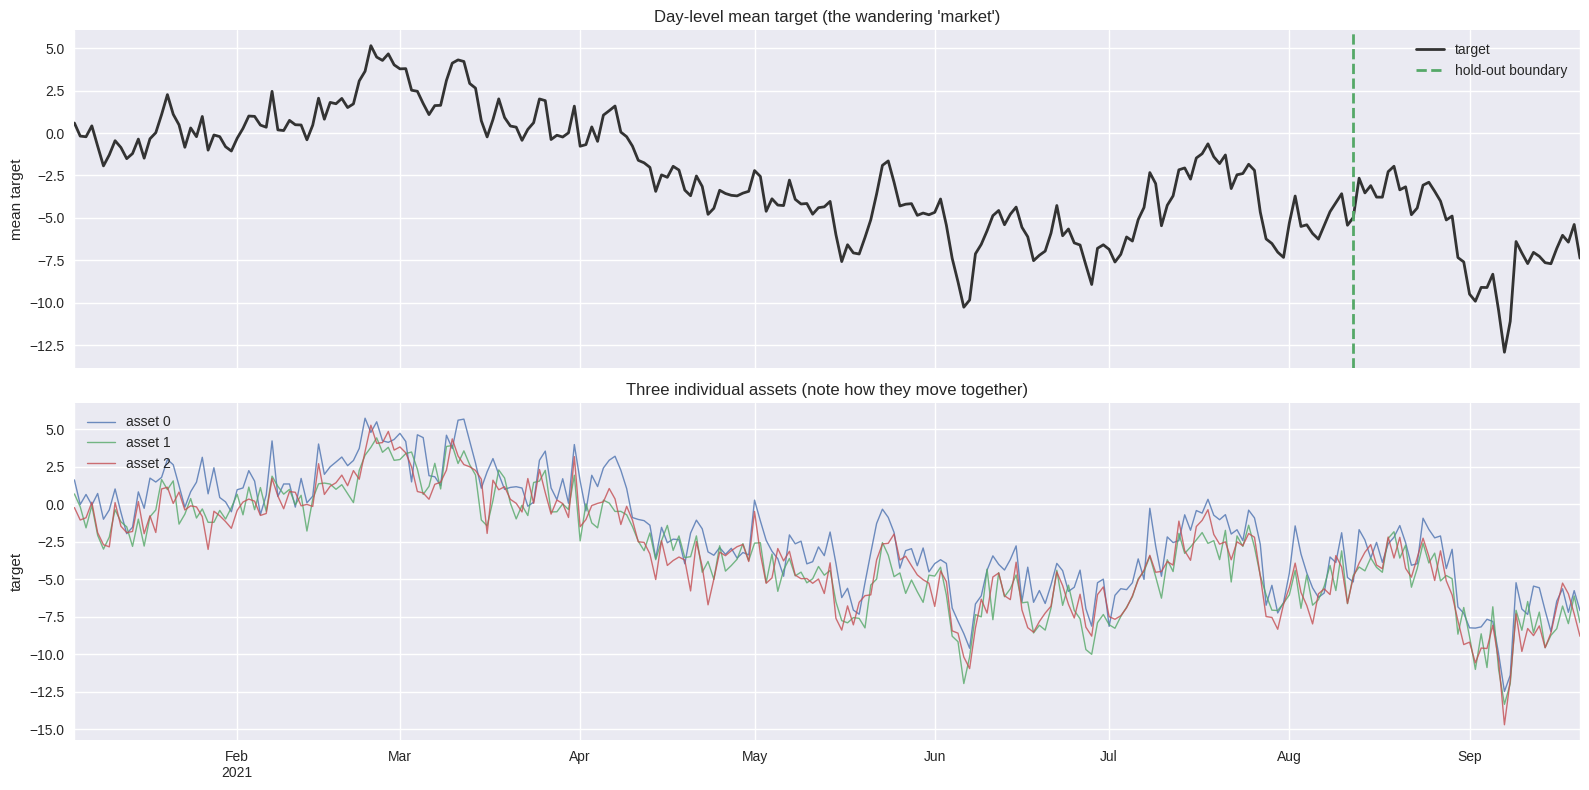

In [10]:
# Plot the raw data before any modelling.
fig, axes = plt.subplots(2, 1, figsize=(CFG.img_dim1, 8), sharex=True)

# Top: the day-level mean target -> reveals the wandering, non-stationary level.
daily_mean = df.groupby("date")["target"].mean()
daily_mean.plot(ax=axes[0], linewidth=2, color="#333333")
axes[0].set(title="Day-level mean target (the wandering 'market')", ylabel="mean target")
axes[0].axvline(daily_mean.index[CFG.cutoff_day], color="#55A868", linestyle="--",
                linewidth=2, label="hold-out boundary")
axes[0].legend()

# Bottom: a few individual asset trajectories -> they move together (shared driver).
for i in range(3):
    sub = df[df["asset_id"] == i]
    axes[1].plot(sub["date"], sub["target"], linewidth=1, alpha=0.8, label=f"asset {i}")
axes[1].set(title="Three individual assets (note how they move together)",
            xlabel="", ylabel="target")
axes[1].legend(loc="upper left")
plt.tight_layout(); plt.show()

A plot of the raw data always comes before any modelling. The top panel shows the **day-level mean target** — averaging across assets strips out per-asset noise and exposes the shared driver `c_t`. Notice its character: it *wanders*, with no fixed level it returns to. That is non-stationarity made visible, and it is the reason the future cannot be read off the past. The green dashed line marks our **hold-out boundary** at day 220; everything to its right is locked away as the untouched future and never used for any fold of any method.

The bottom panel overlays three individual assets. The key observation is that they **move together** — because they all inherit the same daily `c_t`. This is the panel structure that later makes group-aware splitting necessary: any single timestamp is not one observation but twenty correlated ones, and splitting *within* a timestamp leaks that shared state across the train/validation boundary.

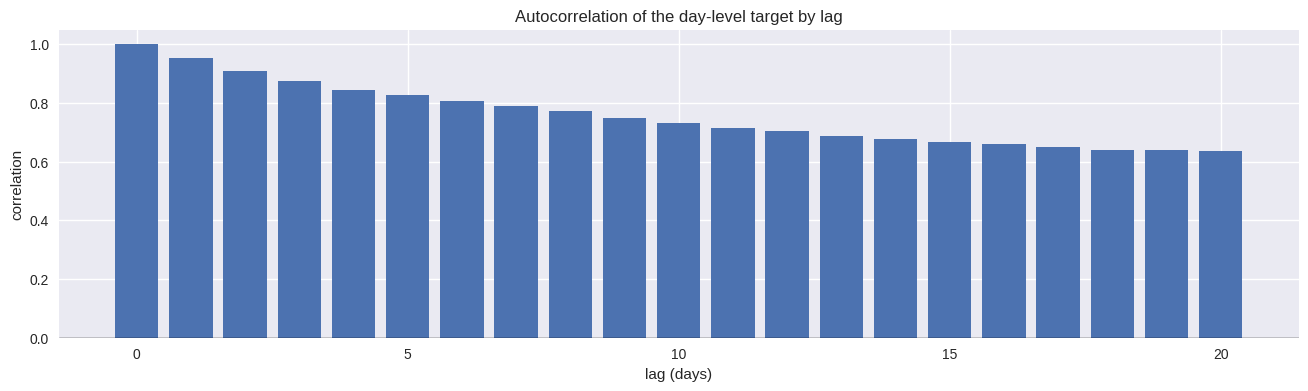

In [11]:
# First-look diagnostic: how serially correlated is the series?
acf = [daily_mean.autocorr(lag=k) for k in range(0, 21)]
plt.figure(figsize=(CFG.img_dim1, 4))
plt.bar(range(0, 21), acf, color="#4C72B0")
plt.axhline(0, color="black", linewidth=1)
plt.title("Autocorrelation of the day-level target by lag")
plt.xlabel("lag (days)"); plt.ylabel("correlation"); plt.show()

Before modelling, one more first-look diagnostic — the **autocorrelation** of the day-level series at lags 0 through 20. `Series.autocorr(lag=k)` measures how strongly the series correlates with a copy of itself shifted by `k` days. Lag 0 is trivially 1.0 (a series correlates perfectly with itself); the story is in how slowly the bars decay.

They decay *slowly*, staying high for many lags. That is the signature of strong **serial correlation**: a day's value is very close to its neighbours'. The validation consequence is direct — if two adjacent days are nearly identical, then putting day *t* in training and day *t+1* in validation gives the model an answer that is almost the question. A method that respects the arrow of time must keep that near-duplicate information on the correct side of the split, and the slower this decay, the more careful it has to be.

In [12]:
# Lock away the future: chronological hold-out, never touched until the very end.
feat_cols = ["t_frac", "lag1", "lag2", "momentum", "n0", "n1", "n2", "n3"]

train_df = df[df["time_id"] <  CFG.cutoff_day].reset_index(drop=True)
test_df  = df[df["time_id"] >= CFG.cutoff_day].reset_index(drop=True)

X_train, y_train = train_df[feat_cols].values, train_df["target"].values
X_test,  y_test  = test_df[feat_cols].values,  test_df["target"].values
groups_train     = train_df["time_id"].values   # the group label = the timestamp

print("train:", X_train.shape, " test:", X_test.shape)

train: (4400, 8)  test: (800, 8)


Now we draw the one split that is sacred: the **chronological hold-out**. Every row before `cutoff_day` (day 220) becomes the development set we will cross-validate on; every row from day 220 onward becomes the test set, sealed off and untouched until the final comparison. The split is by *time*, never random — the test set is literally the future relative to the training data, which is the only honest way to estimate how the model will behave once deployed.

We also fix `feat_cols`, the list of columns the model is allowed to see (notably *excluding* `target`, `time_id`, `asset_id`, and `date`), and extract NumPy arrays for speed. The one extra object is `groups_train`: the `time_id` of each row, which several later splitters need in order to keep a whole timestamp's worth of rows together. The shapes confirm a roughly 4,400-row development panel and an ~800-row future hold-out.

In [13]:
# The GROUND TRUTH: train once on all available history, score once on the sealed future.
reference_model = get_model().fit(X_train, y_train)
true_test_rmse  = rmse(y_test, reference_model.predict(X_test))
print("True generalisation RMSE (the number every CV method is trying to estimate):", true_test_rmse)

True generalisation RMSE (the number every CV method is trying to estimate): 1.7173


This is the reference against which every validation method will be judged. We train a single model on *all* the development history and score it *once* on the sealed future hold-out. Because that hold-out is genuinely later in time and was never involved in any modelling decision, the resulting **true generalisation RMSE** is the closest thing we have to ground truth: it is the real-world error a practitioner would actually suffer.

Hold this number in mind. Every cross-validation scheme below is, in effect, an *attempt to estimate it without peeking at the future*. A good scheme lands close to it. A broken scheme reports something far lower and tells you the model is wonderful — right up until deployment, when reality reasserts itself. The gap between a method's estimate and this number is the `optimism` we defined earlier, and it is the entire subject of what follows.

# The wrong way: shuffled validation

We start at the bottom of the ladder, with the two methods almost everyone reaches for first — and which are, for time series, actively dangerous. Both shuffle the data before splitting, and shuffling is the original sin: it destroys the temporal order that the whole exercise depends on. We keep them not because they work but because the size of their failure is the clearest possible motivation for everything that follows.

## Random split

A single random split holds out a random fraction of rows for validation and trains on the rest. With i.i.d. data this is perfectly reasonable. With a time series it scatters validation rows uniformly across the whole history, so for most of them the model has been trained on rows from *later* dates — it predicts the past using the future.

In [14]:
RANDOM_VAL_FRACTION = 0.25

x0, x1, y0, y1 = train_test_split(
    X_train, y_train, test_size=RANDOM_VAL_FRACTION, random_state=CFG.SEED
)
random_model = get_model().fit(x0, y0)
random_val_rmse = rmse(y1, random_model.predict(x1))

print("Random-split validation RMSE:", random_val_rmse)
print("True generalisation RMSE    :", true_test_rmse)
print("Optimism (val - true)       :", round(random_val_rmse - true_test_rmse, 4))

Random-split validation RMSE: 1.0099
True generalisation RMSE    : 1.7173
Optimism (val - true)       : -0.7074


`train_test_split` with a fixed `random_state` pulls out a random quarter of the development rows as validation and trains on the remaining three-quarters. We score on the held-out quarter and line the number up against the ground truth.

The result is the headline of the whole notebook: the validation RMSE comes in **far below** the true error. The model looks dramatically better than it is. The optimism is large and negative — the scheme has flattered the model by roughly the amount of future information it leaked. Nothing about the model changed; we simply asked it an easier question than reality will. The mechanism is the shared daily driver and the serial correlation we plotted earlier: for a validation row on day *t*, the training set is full of rows from days *t-1*, *t+1*, and from *other assets on day t itself*, all carrying the same wandering `c_t`. Recovering it is trivial — and worthless, because at deployment those neighbours are in the unknowable future.

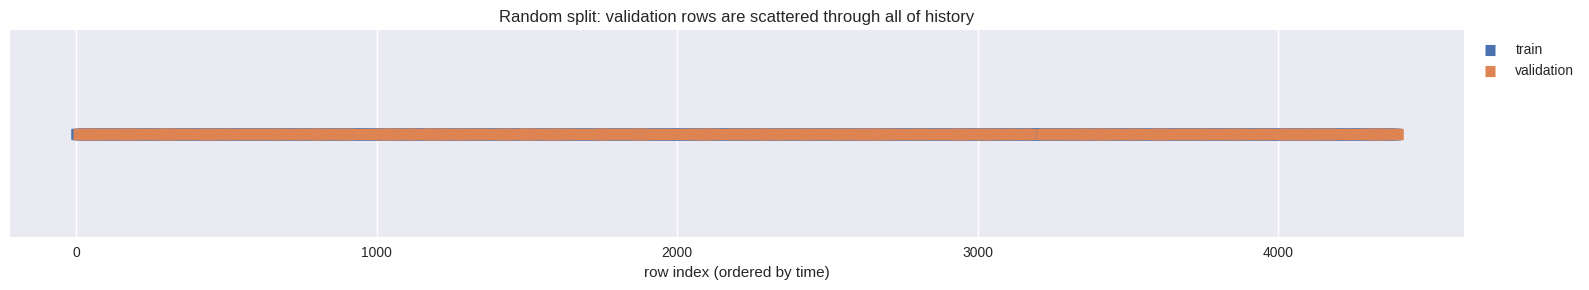

In [15]:
# Make the leakage visible: where do validation rows sit in time?
plt.figure(figsize=(CFG.img_dim1, 3))
val_mask = np.zeros(len(X_train), dtype=bool)
_, val_idx = next(iter([train_test_split(np.arange(len(X_train)),
                                          test_size=RANDOM_VAL_FRACTION,
                                          random_state=CFG.SEED)]))
val_mask[val_idx] = True
plt.scatter(np.where(~val_mask)[0], np.zeros((~val_mask).sum()),
            c="#4C72B0", marker="_", lw=8, label="train")
plt.scatter(np.where(val_mask)[0], np.zeros(val_mask.sum()),
            c="#DD8452", marker="_", lw=8, label="validation")
plt.yticks([]); plt.xlabel("row index (ordered by time)")
plt.title("Random split: validation rows are scattered through all of history")
plt.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0)); plt.tight_layout(); plt.show()

The picture confirms the diagnosis. Orange validation marks are sprinkled across the entire timeline, thoroughly interleaved with blue training marks. There is no point in time before which everything is training and after which everything is validation — the two are shuffled together. Every orange mark with blue marks to its *right* is a row the model "predicts" using information from its future. This is the visual signature of a broken time-series validation, and the methods below will be measured partly by how completely they erase it.

## K-Fold

K-Fold cross-validation is the more respectable cousin: partition the data into *K* folds, use each fold once as validation while training on the other *K−1*, and average the *K* scores. The averaging genuinely reduces the *variance* of the estimate — but if the folds are formed by **shuffling**, every fold inherits exactly the same leakage as a single random split. A more stable estimate of the wrong quantity is still wrong.

In [16]:
kfold = KFold(n_splits=CFG.n_folds, shuffle=True, random_state=CFG.SEED)
kfold_val_rmse = cv_estimate(kfold, X_train, y_train)

print("K-Fold (shuffled) mean validation RMSE:", kfold_val_rmse)
print("True generalisation RMSE              :", true_test_rmse)
print("Optimism (val - true)                 :", round(kfold_val_rmse - true_test_rmse, 4))

K-Fold (shuffled) mean validation RMSE: 1.0062
True generalisation RMSE              : 1.7173
Optimism (val - true)                 : -0.7111


We hand a shuffled `KFold` to our `cv_estimate` engine and average across the five folds. The mean validation RMSE is essentially as optimistic as the single random split — the averaging tightened the estimate without making it honest. The optimism is again large and negative.

It is worth flagging the one defensible case for shuffled K-Fold on time series, raised by Bergmeir and colleagues: if the series is *stationary* and the model's residuals are *uncorrelated* (roughly, a pure autoregression on well-behaved data), K-Fold can validly estimate one-step-ahead error. Our market satisfies neither condition — it is dominated by a non-stationary random walk — so the theoretical escape hatch does not apply, and the empirical optimism confirms it. The lesson generalises: shuffling is only safe when order truly carries no information, which for financial-style data it almost never does.

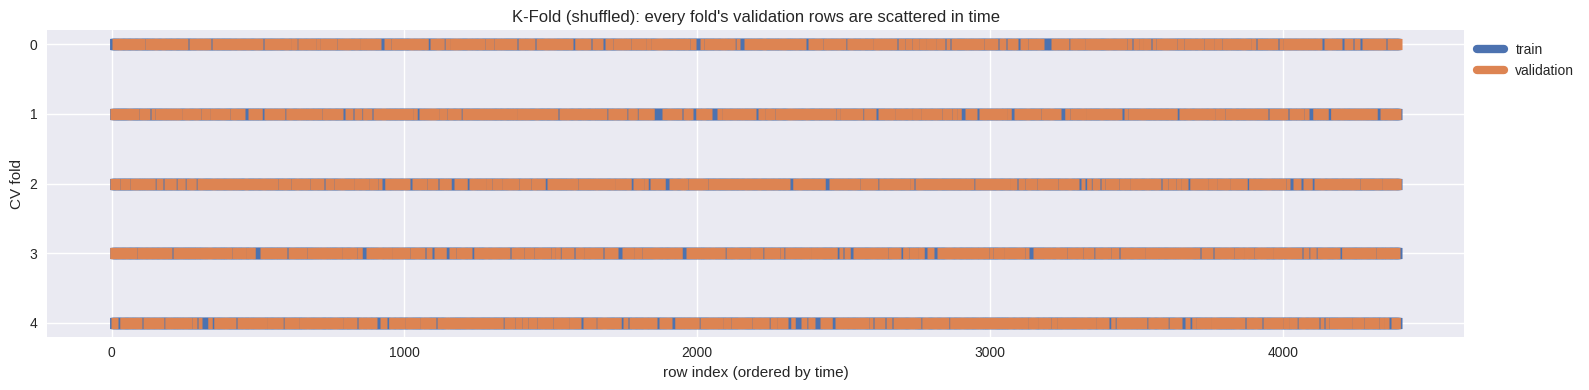

In [17]:
plot_cv_indices(kfold, X_train, groups=None,
                title="K-Fold (shuffled): every fold's validation rows are scattered in time")

The fold-anatomy plot tells the same story five times over. In each row, the orange validation block is spread across the whole timeline rather than sitting cleanly after the training data. K-Fold has changed *which* rows are held out in each fold, but not the fundamental crime: validation rows routinely precede training rows. To fix that we must stop shuffling and start respecting chronology — the subject of the next section.

# Respecting the arrow of time

Everything from here on obeys one rule: **in every split, all training rows come strictly before all validation rows.** That single constraint eliminates the gross leakage we just saw. The remaining methods differ only in how carefully they handle the *boundary* between train and validation, and how many distinct histories they examine.

## Walk-forward validation (`TimeSeriesSplit`)

Walk-forward validation — scikit-learn's `TimeSeriesSplit` — is the foundational honest method. It rolls a forecasting origin forward through time: in the *k*-th fold it trains on the first *k* blocks and validates on the *(k+1)*-th. Training always precedes validation, exactly mirroring how a model is actually used: fit on the past, forecast the future.

In [18]:
ts_split = TimeSeriesSplit(n_splits=CFG.n_folds)   # expanding window (default)
ts_val_rmse = cv_estimate(ts_split, X_train, y_train)

print("TimeSeriesSplit (expanding) mean validation RMSE:", ts_val_rmse)
print("True generalisation RMSE                        :", true_test_rmse)
print("Optimism (val - true)                           :", round(ts_val_rmse - true_test_rmse, 4))

TimeSeriesSplit (expanding) mean validation RMSE: 1.6455
True generalisation RMSE                        : 1.7173
Optimism (val - true)                           : -0.0718


The change in result is night and day. The validation estimate jumps up from the shuffled methods' fantasy figure to something *close to the true error*, and the optimism collapses toward zero. By refusing to let any future row into training, walk-forward validation stops the model from cheating and starts measuring what we actually care about. This is the single most important step on the ladder: from a fundamentally invalid estimate to a fundamentally valid one. Everything after this is refinement.

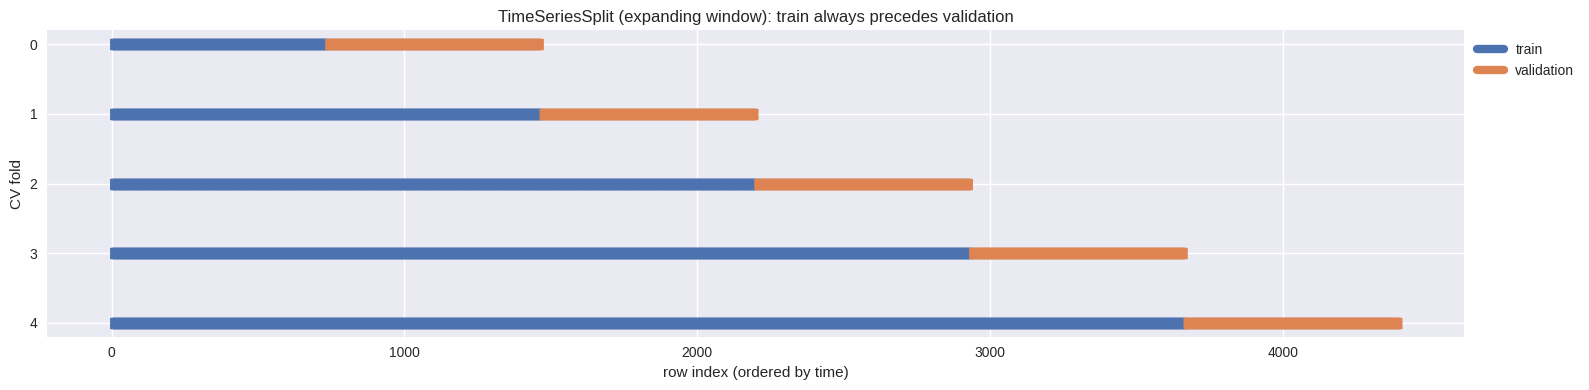

In [19]:
plot_cv_indices(ts_split, X_train, groups=None,
                title="TimeSeriesSplit (expanding window): train always precedes validation")

The anatomy is now unmistakable and exactly what we want. In every fold the blue training block sits entirely to the *left* of the orange validation block — no orange ever precedes blue. As we descend the folds, the training block **grows** (this is the *expanding window*: each fold keeps all prior history) while the validation block marches forward. The forecasting origin rolls rightward through time, one fold at a time, just as a model retrained periodically in production would.

In [20]:
# A fixed-size ("sliding") window: keep only the most recent observations for training.
SLIDING_TRAIN_SIZE = 2 * (X_test.shape[0])   # ~2 hold-out widths of recent rows

ts_sliding = TimeSeriesSplit(n_splits=CFG.n_folds, max_train_size=SLIDING_TRAIN_SIZE)
ts_sliding_val_rmse = cv_estimate(ts_sliding, X_train, y_train)

print("TimeSeriesSplit (sliding) mean validation RMSE:", ts_sliding_val_rmse)
print("Optimism (val - true)                         :", round(ts_sliding_val_rmse - true_test_rmse, 4))

TimeSeriesSplit (sliding) mean validation RMSE: 1.6238
Optimism (val - true)                         : -0.0935


`TimeSeriesSplit` offers a second flavour via `max_train_size`: cap the training window so that, as it slides forward, the oldest rows drop off and only the most recent `SLIDING_TRAIN_SIZE` are kept. The choice between this **sliding** window and the default **expanding** one is not cosmetic — it encodes a belief about the data. An expanding window assumes the process is stable enough that old history still helps; a sliding window assumes the process *drifts* (concept drift, regime change) so that recent data is more representative and stale data may actively mislead. For a wandering, non-stationary market like ours the sliding window is the more defensible hypothesis, though with a series this short the practical difference is modest. Both remain honest — both keep training strictly before validation.

In [21]:
# A subtle residual leak: does row-based splitting ever cut a single day in two?
print("Days appearing in BOTH train and validation (per fold):")
for fold, (tr_idx, val_idx) in enumerate(TimeSeriesSplit(CFG.n_folds).split(X_train)):
    overlap = np.intersect1d(groups_train[tr_idx], groups_train[val_idx])
    print(f"  fold {fold}: {overlap}")

Days appearing in BOTH train and validation (per fold):
  fold 0: [36]
  fold 1: [73]
  fold 2: [110]
  fold 3: [146]
  fold 4: [183]


`TimeSeriesSplit` is honest about *rows*, but our data is grouped by *day*, and it knows nothing about that. It cuts the development set at fixed row positions, and because each day contributes 20 rows, those cut points can land in the *middle* of a day. This check intersects the set of days in each fold's training rows with the days in its validation rows — and finds, at every fold boundary, **one day present on both sides**.

That single shared day is a real, if small, leak: the model trains on some assets from day *D* and is then validated on the *other* assets from the very same day *D*, all of which share that day's market state `c_D`. It is no longer predicting the future of that day — it is filling in a contemporaneous blank it has half-seen. The gross leakage is gone, but a hairline crack remains. Closing it requires a splitter that understands the group structure.

## Group time-series split

The fix is a splitter that combines two ideas: the chronological ordering of `TimeSeriesSplit` and the *never split a group across folds* guarantee of group-aware cross-validation. We want whole days to move from training to validation as indivisible units, so a day is either entirely in the past (training) or entirely in the held-out block — never straddling the line. scikit-learn has no built-in class for this exact combination, so we implement a small, clean one.

In [22]:
class GroupTimeSeriesSplit:
    """Walk-forward CV that keeps every group (here: a whole `time_id`) intact.

    Groups are ordered by first appearance; in fold k the first blocks of groups
    form the training set and the next `group_test_size` groups form validation.
    Training groups always precede validation groups in time.
    """
    def __init__(self, n_splits=5, max_train_size=None):
        self.n_splits = n_splits
        self.max_train_size = max_train_size

    def split(self, X, y=None, groups=None):
        if groups is None:
            raise ValueError("The 'groups' parameter is required.")
        unique, first_idx = np.unique(groups, return_index=True)
        ordered_groups = unique[np.argsort(first_idx)]          # groups in time order
        n_groups = len(ordered_groups)
        n_folds = self.n_splits + 1
        rows_of = {g: np.where(groups == g)[0] for g in ordered_groups}

        group_test_size = n_groups // n_folds
        test_starts = range(n_groups - self.n_splits * group_test_size,
                            n_groups, group_test_size)
        for start in test_starts:
            train_groups = ordered_groups[:start]
            test_groups  = ordered_groups[start:start + group_test_size]
            train_idx = np.sort(np.concatenate([rows_of[g] for g in train_groups]))
            if self.max_train_size and len(train_idx) > self.max_train_size:
                train_idx = train_idx[-self.max_train_size:]
            test_idx = np.sort(np.concatenate([rows_of[g] for g in test_groups]))
            yield train_idx, test_idx

The class mirrors scikit-learn's splitter interface — a `.split()` method yielding (train, validation) index arrays — so it drops straight into our `cv_estimate` engine with no other change.

The logic works in *group* space rather than row space. First it lists the unique groups (our `time_id`s) and orders them by first appearance, so `ordered_groups` runs in true chronological order. It precomputes `rows_of`, a lookup from each group to the row indices belonging to it. Then it walks the forecasting origin forward exactly as `TimeSeriesSplit` does, but moving *whole groups*: at each step the earlier groups become training and the next `group_test_size` groups become validation, and the row indices are reconstituted by unioning the member rows of those groups. Because a group's rows are only ever assigned as a block, **no day can land on both sides of a split**. The optional `max_train_size` gives us the same expanding-vs-sliding choice as before, now measured in rows after the group union.

In [23]:
group_cv = GroupTimeSeriesSplit(n_splits=CFG.n_folds)

# Confirm the boundary leak is gone.
print("Days appearing in BOTH train and validation (per fold):")
for fold, (tr_idx, val_idx) in enumerate(group_cv.split(X_train, groups=groups_train)):
    print(f"  fold {fold}: {np.intersect1d(groups_train[tr_idx], groups_train[val_idx])}")

group_val_rmse = cv_estimate(group_cv, X_train, y_train, groups=groups_train)
print("\nGroupTimeSeriesSplit mean validation RMSE:", group_val_rmse)
print("Optimism (val - true)                    :", round(group_val_rmse - true_test_rmse, 4))

Days appearing in BOTH train and validation (per fold):
  fold 0: []
  fold 1: []
  fold 2: []
  fold 3: []
  fold 4: []



GroupTimeSeriesSplit mean validation RMSE: 1.6868
Optimism (val - true)                    : -0.0305


The overlap check now prints **empty arrays** at every fold: not a single day is shared between training and validation. The hairline crack from the previous section is sealed. The validation RMSE remains close to the true error, with optimism near zero — confirming that on this panel, group-aware splitting is the correct minimum standard, removing the last of the *contemporaneous* leakage without sacrificing honesty.

It is worth being precise about what this method is and isn't. `GroupTimeSeriesSplit` is not a blanket upgrade over `TimeSeriesSplit` — for a plain univariate series with one row per timestamp there are no groups to protect and the two coincide. It is the *necessary adaptation for panel data*, where each timestamp bundles many correlated observations. The data structure dictates the method.

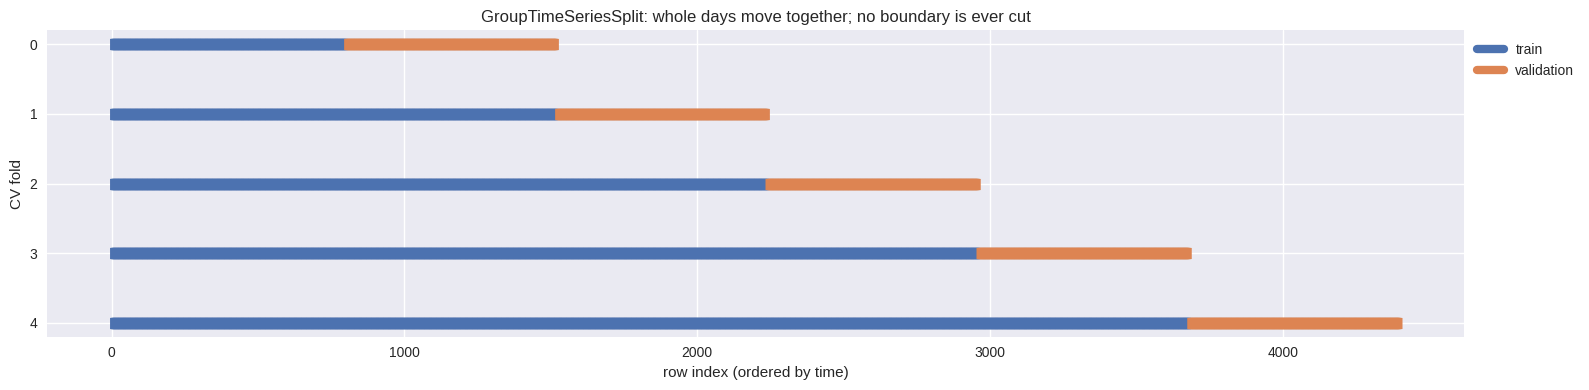

In [24]:
plot_cv_indices(group_cv, X_train, groups=groups_train,
                title="GroupTimeSeriesSplit: whole days move together; no boundary is ever cut")

Visually this looks much like the walk-forward staircase, which is the point — the difference lives at the boundaries, where the train/validation cut now always falls *between* days rather than through one. Train precedes validation, blocks are clean, and every day is indivisible. We have a valid, group-respecting estimate. The one remaining vulnerability is hiding inside a feature.

## Purged group time-series split

One feature in our data, `momentum`, is a rolling mean over the previous `window` days. Its value on the first day of a validation block was computed partly from days that sit *inside the preceding training block* — and, symmetrically, training rows just before a validation block carry rolling features that reach *into* it. This is **path-dependency leakage**: a feature's information footprint spills across the train/validation boundary even though no individual row does. The fix has two named parts, both due to Marcos López de Prado:

- **Purging** removes training observations whose labels or features overlap, in time, with the validation period.
- **Embargoing** additionally drops a small buffer of observations *immediately after* the validation block before resuming training, since serially-correlated features there are still contaminated by the validation period.

In practice both amount to inserting a **gap** of a few groups between training and validation — sized to the look-back/look-ahead horizon of your features and labels.

In [25]:
class PurgedGroupTimeSeriesSplit:
    """GroupTimeSeriesSplit with a `group_gap`: drop `group_gap` groups immediately
    before each validation block, breaking the overlap created by rolling-window
    features and path-dependent labels (purging + embargo).
    """
    def __init__(self, n_splits=5, group_gap=0, max_train_size=None):
        self.n_splits = n_splits
        self.group_gap = group_gap
        self.max_train_size = max_train_size

    def split(self, X, y=None, groups=None):
        if groups is None:
            raise ValueError("The 'groups' parameter is required.")
        unique, first_idx = np.unique(groups, return_index=True)
        ordered_groups = unique[np.argsort(first_idx)]
        n_groups = len(ordered_groups)
        n_folds = self.n_splits + 1
        rows_of = {g: np.where(groups == g)[0] for g in ordered_groups}

        group_test_size = n_groups // n_folds
        test_starts = range(n_groups - self.n_splits * group_test_size,
                            n_groups, group_test_size)
        for start in test_starts:
            train_end = max(0, start - self.group_gap)          # <-- the purge/embargo gap
            train_groups = ordered_groups[:train_end]
            test_groups  = ordered_groups[start:start + group_test_size]
            train_idx = np.sort(np.concatenate([rows_of[g] for g in train_groups])) \
                        if len(train_groups) else np.array([], dtype=int)
            if self.max_train_size and len(train_idx) > self.max_train_size:
                train_idx = train_idx[-self.max_train_size:]
            test_idx = np.sort(np.concatenate([rows_of[g] for g in test_groups]))
            yield train_idx, test_idx

This class is `GroupTimeSeriesSplit` with a single addition, marked in the code: instead of training on every group up to the validation block, it stops `group_gap` groups *short* of it. Those skipped groups form the purge/embargo buffer — they are old enough to sit before the validation block, but recent enough that their rolling features overlap it, so excluding them severs the contamination.

Everything else is identical: groups are ordered by time, validation blocks march forward, whole days stay intact. The only cost is the handful of training groups sacrificed to the gap — which is exactly why the estimate will edge toward *conservatism*. We set the gap equal to the feature's `window` so that no rolling feature in any training row can possibly reach into a validation block.

In [26]:
purged_cv = PurgedGroupTimeSeriesSplit(n_splits=CFG.n_folds, group_gap=CFG.window)
purged_val_rmse = cv_estimate(purged_cv, X_train, y_train, groups=groups_train)

print(f"PurgedGroupTimeSeriesSplit (gap={CFG.window}) mean validation RMSE:", purged_val_rmse)
print("True generalisation RMSE                                  :", true_test_rmse)
print("Optimism (val - true)                                     :", round(purged_val_rmse - true_test_rmse, 4))

PurgedGroupTimeSeriesSplit (gap=10) mean validation RMSE: 2.1769
True generalisation RMSE                                  : 1.7173
Optimism (val - true)                                     : 0.4596


With the gap in place the validation estimate moves to the *conservative* side of the truth — optimism is now small and **positive**. Read that correctly: it is a feature, not a bug. We have traded a little training data, and a slightly pessimistic point estimate, for the assurance that no rolling-feature leakage is inflating our confidence. In a setting where the cost of overestimating a model is catastrophic — deploying a strategy that quietly loses money — a method that errs toward caution is exactly what you want. Compared with the shuffled methods that under-reported the error by a wide margin, a small over-report is a bargain.

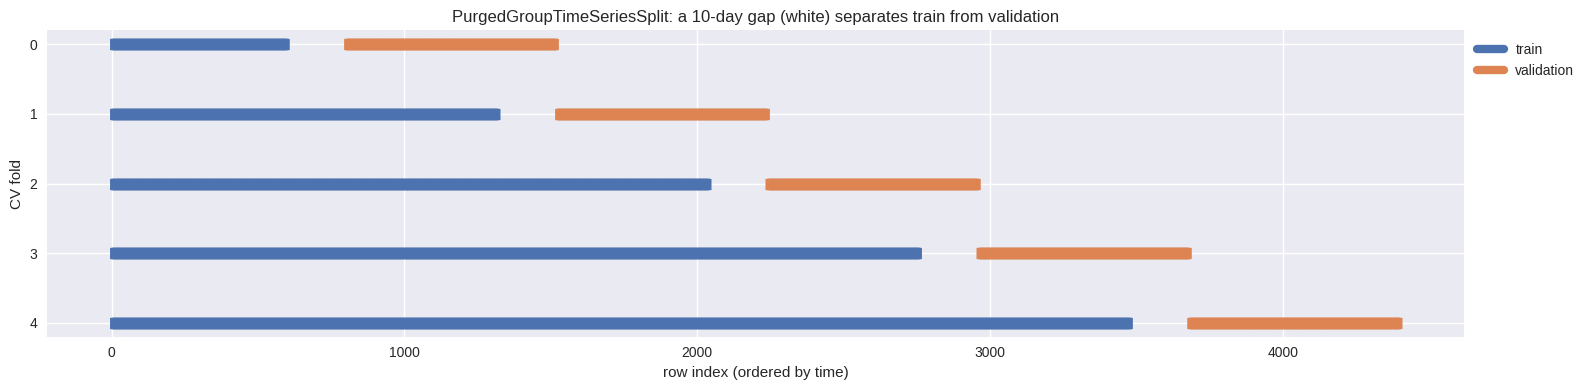

In [27]:
plot_cv_indices(purged_cv, X_train, groups=groups_train,
                title=f"PurgedGroupTimeSeriesSplit: a {CFG.window}-day gap (white) separates train from validation")

The gap is now visible as a strip of whitespace between the end of each blue training block and the start of the orange validation block. That deliberate emptiness is the purge/embargo buffer: the days whose rolling features straddle the boundary, removed so they cannot leak. Train precedes validation, days stay whole, and the boundary is no longer a seam through which path-dependent information can seep. This is, for a single historical path, about as rigorous as it gets — which raises the last question: why trust a single path at all?

# Beyond a single path: Combinatorial Purged CV

Every method so far, however careful, evaluates the model along **one** sequence of events — the actual history, walked forward once. Its verdict is therefore conditional on that single path. If our history happened to be unusually kind (or unusually harsh), the estimate is correspondingly biased, and we have no way to tell. This is *backtest overfitting* at the level of the evaluation itself: a strategy can be overfit to the one path it was tested on.

**Combinatorial Purged Cross-Validation (CPCV)** breaks that dependence. Divide the timeline into *N* ordered blocks, then form *every* combination that holds out *k* blocks for testing and trains on the rest, purging around each test block as before. Stitching the held-out predictions back together yields not one backtest path but several, and therefore not a single score but a **distribution** of scores.

In [28]:
class CombinatorialPurgedGroupKFold:
    """Test on every combination of `n_test_splits` out of `n_splits` ordered group-blocks,
    purging a buffer around each test block. Yields many train/test folds whose
    held-out segments combine into multiple backtest paths.
    """
    def __init__(self, n_splits=6, n_test_splits=2, purge=1, pct_embargo=0.01):
        self.n_splits = n_splits
        self.n_test_splits = n_test_splits
        self.purge = purge
        self.pct_embargo = pct_embargo

    def split(self, X, y=None, groups=None):
        if groups is None:
            raise ValueError("The 'groups' parameter is required.")
        unique, first_idx = np.unique(groups, return_index=True)
        ordered_groups = unique[np.argsort(first_idx)]
        n_groups = len(ordered_groups)
        rows_of = {g: np.where(groups == g)[0] for g in ordered_groups}

        embargo = int(n_groups * self.pct_embargo)
        block_size = n_groups // self.n_splits
        blocks = {}
        for b in range(self.n_splits):
            lo = b * block_size
            hi = (b + 1) * block_size if b < self.n_splits - 1 else n_groups
            blocks[b] = list(ordered_groups[lo:hi])

        for test_blocks in combinations(range(self.n_splits), self.n_test_splits):
            test_groups, banned = [], []
            for b in test_blocks:
                test_groups += blocks[b]
                first, last = blocks[b][0], blocks[b][-1]
                banned += list(ordered_groups[max(0, first - self.purge):first])          # purge before
                last_pos = np.where(ordered_groups == last)[0][0]
                banned += list(ordered_groups[last_pos + 1: last_pos + 1 + self.purge + embargo])  # embargo after
            train_groups = [g for g in ordered_groups if g not in banned and g not in test_groups]
            train_idx = np.sort(np.concatenate([rows_of[g] for g in train_groups]))
            test_idx  = np.sort(np.concatenate([rows_of[g] for g in test_groups]))
            yield train_idx, test_idx

The implementation generalises the purged splitter from a single forward sweep to *all* combinations. It cuts the ordered groups into `n_splits` contiguous blocks, then iterates with `itertools.combinations` over every way of choosing `n_test_splits` of those blocks to serve as the test set at once. For each combination it bans a small buffer of groups around every chosen block — `purge` groups immediately before and `purge + embargo` groups immediately after — and trains on whatever ordered groups remain. Critically, the test blocks need not be contiguous, so a single fold can probe two disjoint stretches of history simultaneously; that is what manufactures *alternative* paths rather than just re-slicing the one.

Note that here the held-out blocks function as test segments stitched into paths, so the splitter is naturally evaluated on its own out-of-sample blocks rather than through the development-vs-truth framing we used above.

In [29]:
# How many folds and how many distinct backtest paths does our choice yield?
N_BLOCKS, K_TEST = 6, 2
n_folds = comb(N_BLOCKS, K_TEST, exact=True)
n_paths = n_folds * K_TEST // N_BLOCKS
print(f"N={N_BLOCKS} blocks, k={K_TEST} test blocks per fold")
print(f"  number of folds : C({N_BLOCKS},{K_TEST}) = {n_folds}")
print(f"  number of paths : {n_folds} * {K_TEST} / {N_BLOCKS} = {n_paths}")

N=6 blocks, k=2 test blocks per fold
  number of folds : C(6,2) = 15
  number of paths : 15 * 2 / 6 = 5


A quick combinatorial sanity check before running anything. With *N = 6* blocks and *k = 2* test blocks per fold, there are $\binom{6}{2} = 15$ folds. Because each fold tests 2 of the 6 blocks and, across all folds, the testing is spread uniformly over the blocks, the number of complete backtest **paths** is $15 \times 2 / 6 = 5$. So this single configuration will give us five alternative histories to compare — five chances for the model to look good or bad — instead of the lone path every earlier method offered.

In [30]:
cpcv = CombinatorialPurgedGroupKFold(n_splits=N_BLOCKS, n_test_splits=K_TEST)
_, cpcv_scores = cv_estimate(cpcv, X_train, y_train, groups=groups_train, return_scores=True)

cpcv_mean = float(np.round(np.mean(cpcv_scores), 4))
cpcv_std  = float(np.round(np.std(cpcv_scores), 4))
print("CPCV per-fold RMSEs :", [round(s, 3) for s in cpcv_scores])
print("CPCV mean RMSE      :", cpcv_mean, " | std:", cpcv_std)
print("True generalisation :", true_test_rmse)

CPCV per-fold RMSEs : [1.587, 1.492, 1.597, 1.773, 1.796, 1.432, 1.582, 1.778, 1.687, 1.92, 1.827, 1.938, 1.867, 1.958, 1.614]
CPCV mean RMSE      : 1.7232  | std: 0.1609
True generalisation : 1.7173


Running CPCV through the same engine — this time keeping every fold's score via `return_scores=True` — yields a *vector* of RMSEs rather than a lone number. Two facts stand out. The **mean** sits essentially on top of the true generalisation error: averaged over many purged combinations, CPCV is an excellent point estimate. And the **standard deviation** is non-trivial: the model's measured error swings noticeably depending on which stretch of history it is tested against. That spread is information no single-path method could ever surface — it is a direct readout of how sensitive the model is to the regime it happens to face.

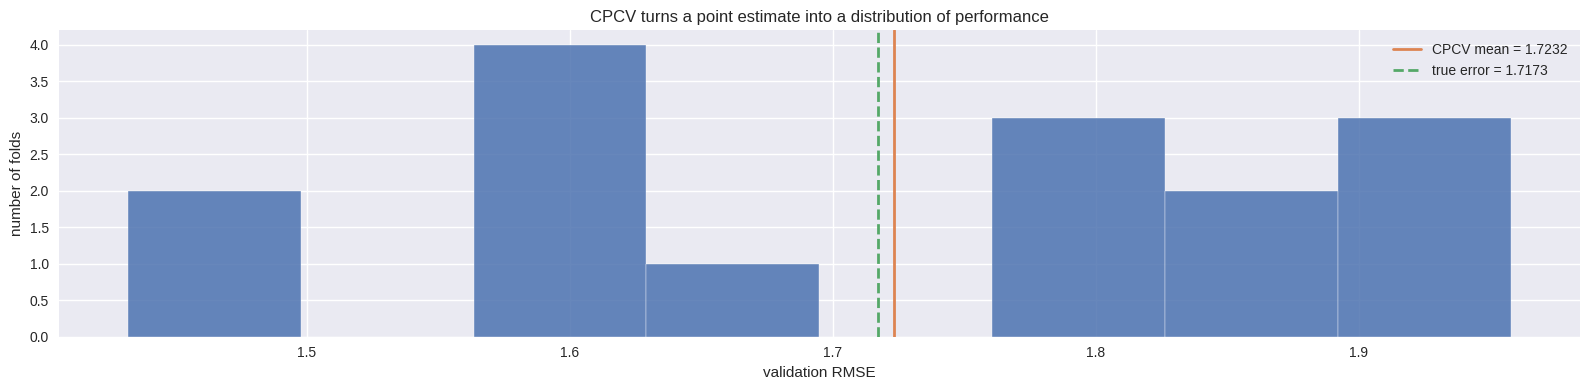

In [31]:
plt.figure(figsize=(CFG.img_dim1, 4))
plt.hist(cpcv_scores, bins=8, color="#4C72B0", edgecolor="white", alpha=0.85)
plt.axvline(cpcv_mean, color="#DD8452", linestyle="-", linewidth=2,
            label=f"CPCV mean = {cpcv_mean}")
plt.axvline(true_test_rmse, color="#55A868", linestyle="--", linewidth=2,
            label=f"true error = {true_test_rmse}")
plt.title("CPCV turns a point estimate into a distribution of performance")
plt.xlabel("validation RMSE"); plt.ylabel("number of folds")
plt.legend(); plt.tight_layout(); plt.show()

The histogram is the payoff of the whole notebook. Where every earlier method handed us a single bar — one number, take it or leave it — CPCV hands us a *shape*. The orange line (CPCV's mean) lands almost exactly on the green line (the true error), and the width of the distribution quantifies our uncertainty about that estimate. This reframes the practitioner's question. Instead of "what is the error?" we can now ask "what is the *worst* error across plausible histories?", "how often does the model do badly?", and "could this apparent skill be a fluke of one lucky path?" Turning validation from a point estimate into a distribution is what elevates it from performance reporting to genuine **risk assessment**.

# Putting it together: the comparison

We have walked one dataset down the full ladder. Now we collect every verdict into a single table, so the progression from dangerous self-deception to honest, distribution-aware evaluation is visible at a glance.

In [32]:
results = [
    summarise("Random split",            random_val_rmse,    true_test_rmse),
    summarise("K-Fold (shuffled)",        kfold_val_rmse,     true_test_rmse),
    summarise("TimeSeriesSplit",          ts_val_rmse,        true_test_rmse),
    summarise("GroupTimeSeriesSplit",     group_val_rmse,     true_test_rmse),
    summarise("PurgedGroupTimeSeriesSplit", purged_val_rmse,  true_test_rmse),
    summarise("CPCV (mean of paths)",     cpcv_mean,          true_test_rmse),
]
results_df = pd.DataFrame(results)
results_df

,method,cv_val_rmse,true_test_rmse,optimism
0,Random split,1.0099,1.7173,-0.7074
1,K-Fold (shuffled),1.0062,1.7173,-0.7111
2,TimeSeriesSplit,1.6455,1.7173,-0.0718
3,GroupTimeSeriesSplit,1.6868,1.7173,-0.0305
4,PurgedGroupTimeSeriesSplit,2.1769,1.7173,0.4596
5,CPCV (mean of paths),1.7232,1.7173,0.0059


The table lays the whole argument bare. Read the `optimism` column top to bottom: the two shuffled methods post large **negative** values — they told us the model was far better than it is. `TimeSeriesSplit` and `GroupTimeSeriesSplit` sit near **zero** — honest. `PurgedGroupTimeSeriesSplit` tips slightly **positive** — safely conservative. And CPCV's mean lands right on the truth while (as we saw) also carrying a measure of its own uncertainty. The same model, the same data, the same metric throughout: every difference in this column is caused purely by the **choice of validation scheme**.

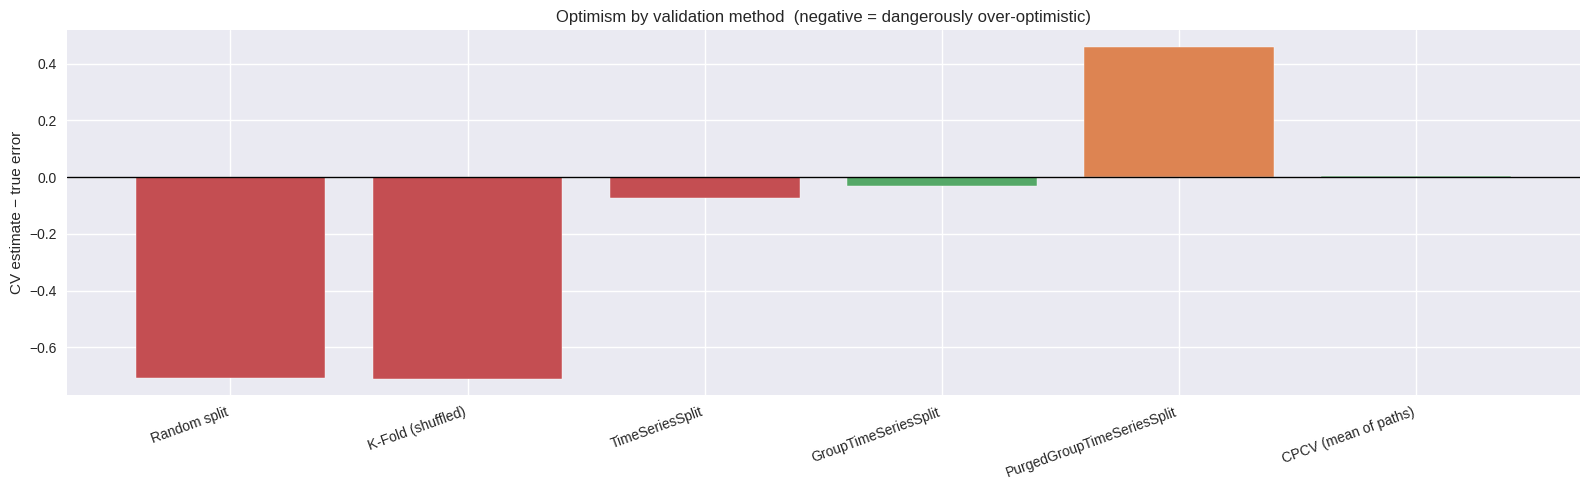

In [33]:
order = results_df["method"].tolist()
colors = ["#C44E52" if o < -0.05 else "#55A868" if abs(o) <= 0.05 else "#DD8452"
          for o in results_df["optimism"]]
plt.figure(figsize=(CFG.img_dim1, 5))
plt.bar(order, results_df["optimism"], color=colors, edgecolor="white")
plt.axhline(0, color="black", linewidth=1)
plt.title("Optimism by validation method  (negative = dangerously over-optimistic)")
plt.ylabel("CV estimate − true error"); plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.show()

The same numbers as a bar chart, coloured by verdict: red where the method dangerously under-reports error, green where it is honest, orange where it is conservatively safe. The visual collapse from the tall red bars on the left to the small green/orange bars on the right *is* the lesson of the notebook. Moving rightward, each method removes one specific leak — shuffling, then intra-group contamination, then path-dependency — and the bar shrinks accordingly.

## Summary table of validation strategies

Pulling back from our one experiment to the general properties of each method:

| Feature | Random Split | K-Fold | TimeSeriesSplit | GroupTimeSeriesSplit | PurgedGroupTimeSeriesSplit | CPCV |
| :-- | :-- | :-- | :-- | :-- | :-- | :-- |
| Respects temporal order | No | No | Yes | Yes | Yes | Yes (within paths) |
| Blocks standard leakage | No | No | Yes | Yes | Yes | Yes |
| Blocks path-dependent leakage | No | No | No | No | Yes (purge/embargo) | Yes (purge/embargo) |
| Handles grouped/panel data | No | No | No | Yes | Yes | Yes |
| Robustness of estimate | Very low | Very low | Path-dependent | Path-dependent | Path-dependent | High (distributional) |
| Computational cost | Low | Low | Medium | Medium | Medium–high | Very high |
| Observed optimism (this notebook) | Extreme | Extreme | Low | Low | Minimal (safe) | Minimal (+ spread) |

Each column adds exactly one capability to the one before it — the same one-concept-per-rung ladder we climbed in code.

## A practitioner's guide to choosing

The table is not a ranking to read bottom-up and always pick the last row; the right method is the simplest one that covers your data's actual hazards:

- **A plain univariate series, simple features and labels** → start with **`TimeSeriesSplit`**. Choose an *expanding* window if you believe the process is stable, a *sliding* window if you expect drift and want recency to dominate. This is a valid baseline and often enough.
- **Panel data — many entities sharing each timestamp** (our case; daily data for many assets) → **`GroupTimeSeriesSplit`** is the minimum bar, to stop one timestamp's rows leaking across the split.
- **Engineered rolling features or path-dependent labels** (moving averages, momentum, triple-barrier labels) → upgrade to **purging and embargoing**, sized to your features' look-back and your labels' look-ahead. This is the only reliable defence against the leakage whose footprint exceeds a single row.
- **High-stakes strategy selection and risk assessment** → reach for **CPCV**. When you need to know not just the expected performance but its fragility — the worst case, the variance, the odds that apparent skill is luck — the distribution it produces is worth its considerable compute cost.

The meta-lesson outlives any single tool: **the validation scheme must match the structure of the data and the cost of being wrong.** Reaching for a shuffled split on temporal data is not a small inaccuracy — it is the difference between a number you can act on and a number that will betray you the moment the model meets the future.

---

That completes the tour. We started by fabricating a market we fully understood, established the true error we were trying to estimate, and then watched six validation schemes attempt that estimate — from random splitting, which under-reported the error so badly it would have shipped a broken model, to Combinatorial Purged CV, which not only recovered the true error on average but quantified how much we should trust it. The arrow of time was the thread throughout: respect it, account for the way information clusters in groups and spreads through engineered features, and stop trusting any single history more than it deserves.